# So sánh mô hình Tree-based — Dự báo PM2.5 (t + 24h)

Notebook huấn luyện và đối chiếu **Random Forest**, **XGBoost**, **LightGBM** trên bộ đã chọn feature ([`modeling_fs/train_tree.csv`](../data/processed/modeling_fs/train_tree.csv), `val_tree`, `test_tree`).

- **Target:** `target_pm25_h24` (µg/m³, 24 giờ sau).
- **Đặc trưng:** toàn bộ cột số trừ `datetime_local`.
- **Đánh giá:** RMSE, MAE, MAPE trên tập **test** (và bảng tổng hợp train/val/test).
- **Trực quan:** biểu đồ cột so sánh metric; scatter Actual vs Predicted trên test; (tùy chọn) chuỗi thời gian một đoạn test.

**Lưu ý:** Siêu tham số giữ ở mức hợp lý mặc định để so sánh công bằng; tinh chỉnh có thể làm sau trên validation.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELING = Path("../data/processed/modeling_fs")
TARGET = "target_pm25_h24"


In [2]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = mean_absolute_error(y_true, y_pred)
    eps = 1e-6
    mask = np.abs(y_true) > eps
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}


def load_xy(path: Path):
    df = pd.read_csv(path, parse_dates=["datetime_local"])
    feat = [c for c in df.columns if c not in ("datetime_local", TARGET)]
    return df[feat], df[TARGET], df["datetime_local"]

train_X, train_y, train_dt = load_xy(MODELING / "train_tree.csv")
val_X, val_y, val_dt = load_xy(MODELING / "val_tree.csv")
test_X, test_y, test_dt = load_xy(MODELING / "test_tree.csv")
print(train_X.shape, val_X.shape, test_X.shape)


(6383, 26) (2128, 26) (2128, 26)


In [3]:
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=200,
        max_depth=8,
        num_leaves=63,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbose=-1,
    ),
}

fitted = {}
preds_test = {}
preds_val = {}

for name, est in models.items():
    est.fit(train_X, train_y)
    fitted[name] = est
    preds_val[name] = est.predict(val_X)
    preds_test[name] = est.predict(test_X)
    print(name, "fit xong")


RandomForest fit xong
XGBoost fit xong
LightGBM fit xong


In [4]:
rows = []
for name in models:
    for split, y_t, y_p in [
        ("train", train_y, fitted[name].predict(train_X)),
        ("val", val_y, preds_val[name]),
        ("test", test_y, preds_test[name]),
    ]:
        m = regression_metrics(y_t, y_p)
        rows.append({"model": name, "split": split, **m})

metrics_df = pd.DataFrame(rows)
metrics_df


,model,split,RMSE,MAE,MAPE
0,RandomForest,train,4.213195,2.557059,9.614426
1,RandomForest,val,14.633528,10.905377,46.946281
2,RandomForest,test,21.121901,15.079946,44.759541
3,XGBoost,train,3.994933,2.772678,10.316646
4,XGBoost,val,15.146070,11.234026,46.464364
5,XGBoost,test,19.995623,14.704553,43.331722
6,LightGBM,train,4.796219,3.197549,11.670467
7,LightGBM,val,15.006974,11.199531,46.685669
8,LightGBM,test,20.377557,14.892250,43.464353


In [5]:
# Bảng pivot: test only (để so sánh mô hình)
test_metrics = metrics_df[metrics_df["split"] == "test"].set_index("model")[["RMSE", "MAE", "MAPE"]]
test_metrics.round(4)


,RMSE,MAE,MAPE
model,,,
RandomForest,21.1219,15.0799,44.7595
XGBoost,19.9956,14.7046,43.3317
LightGBM,20.3776,14.8923,43.4644


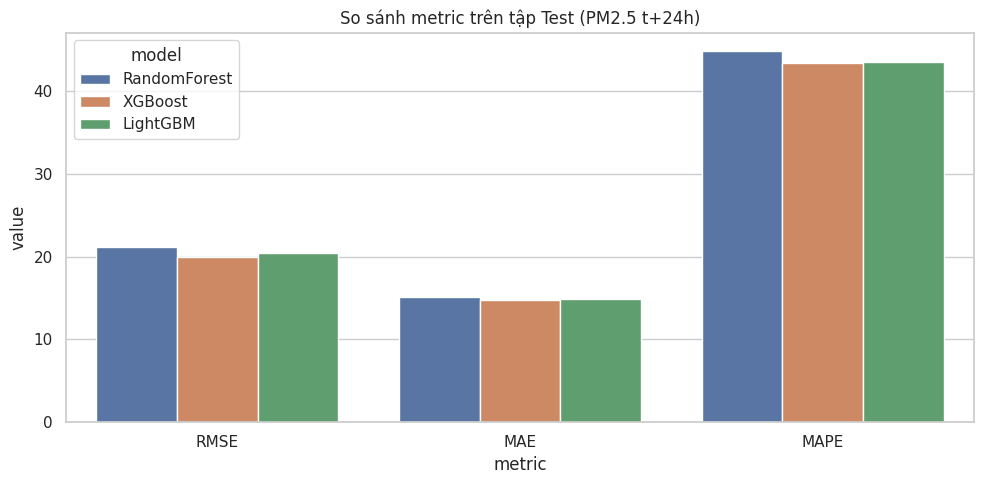

Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/figures/tree_models_test_metrics_bar.png


In [6]:
# Biểu đồ cột: RMSE / MAE / MAPE trên test
plot_df = metrics_df[metrics_df["split"] == "test"].melt(
    id_vars=["model"], value_vars=["RMSE", "MAE", "MAPE"], var_name="metric", value_name="value"
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x="metric", y="value", hue="model", ax=ax)
ax.set_title("So sánh metric trên tập Test (PM2.5 t+24h)")
plt.tight_layout()
out_bar = FIG_DIR / "tree_models_test_metrics_bar.png"
fig.savefig(out_bar, dpi=150)
plt.show()
print("Đã lưu:", out_bar.resolve())


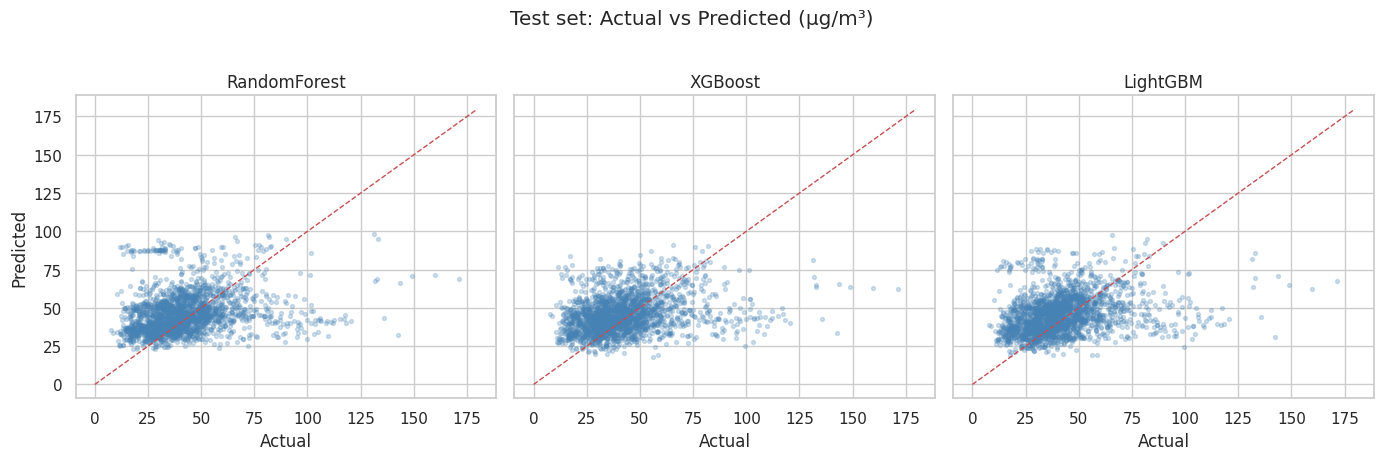

Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/figures/tree_models_test_actual_vs_predicted.png


In [7]:
# Scatter: Actual vs Predicted (test) — 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
lim = float(test_y.max()) * 1.05
for ax, name in zip(axes, models.keys()):
    y_p = preds_test[name]
    ax.scatter(test_y, y_p, alpha=0.25, s=8, c="steelblue")
    ax.plot([0, lim], [0, lim], "r--", lw=1, label="y=x")
    ax.set_xlabel("Actual")
    ax.set_title(name)
axes[0].set_ylabel("Predicted")
fig.suptitle("Test set: Actual vs Predicted (µg/m³)", y=1.02)
plt.tight_layout()
out_sc = FIG_DIR / "tree_models_test_actual_vs_predicted.png"
fig.savefig(out_sc, dpi=150)
plt.show()
print("Đã lưu:", out_sc.resolve())


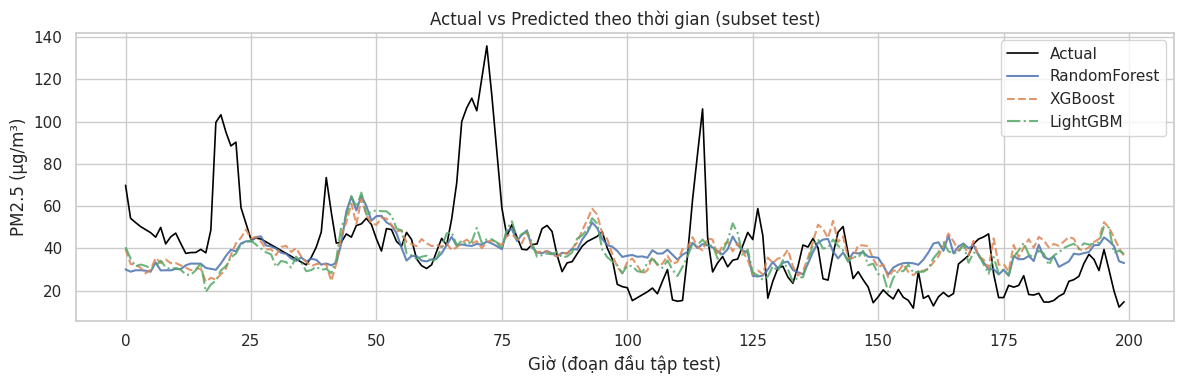

Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/figures/tree_models_test_timeseries_subset.png


In [8]:
# Chuỗi thời gian (test): 200 giờ đầu để nhìn rõ
k = min(200, len(test_dt))
fig, ax = plt.subplots(figsize=(12, 4))
idx = np.arange(k)
ax.plot(idx, test_y.iloc[:k].values, label="Actual", color="black", lw=1.2)
for name, style in zip(models.keys(), ["-", "--", "-."]):
    ax.plot(idx, preds_test[name][:k], label=name, linestyle=style, alpha=0.85)
ax.set_xlabel("Giờ (đoạn đầu tập test)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
ax.set_title("Actual vs Predicted theo thời gian (subset test)")
plt.tight_layout()
out_ts = FIG_DIR / "tree_models_test_timeseries_subset.png"
fig.savefig(out_ts, dpi=150)
plt.show()
print("Đã lưu:", out_ts.resolve())


In [9]:
# Lưu bảng metric ra CSV
out_csv = Path("../outputs/predictions/tree_model_metrics.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(out_csv, index=False)
print("Đã lưu:", out_csv.resolve())


Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/predictions/tree_model_metrics.csv
